# AI-Driven Financial Statement Sentiment Analysis  
**An NLP & Multi-Agent AI Approach Based on Earnings Call Transcripts**


## 1. Introduction
### 1.1 Project Background

Earnings call transcripts contain forward-looking qualitative information that is not fully reflected in traditional numerical financial indicators. While financial statements summarize realized performance, managerial responses during earnings calls often reveal expectations, confidence levels, risk perception, and strategic outlook.

Such linguistic signals may influence investor expectations, analyst revisions, and short-term asset price dynamics. In particular, changes in managerial tone can serve as event-driven communication signals and potentially act as text-based risk indicators.

Recent advances in Natural Language Processing (NLP), especially transformer-based financial language models, have enabled systematic extraction of structured sentiment measures from large-scale financial text. These developments make it possible to transform qualitative disclosures into quantitative variables suitable for financial analysis and risk modeling.

### 1.2 Project Objective

The objective of this project is to develop an NLP-based analytical framework that extracts structured sentiment indicators from earnings call transcripts and transforms them into text-based risk factors for financial interpretation.

Specifically, the framework focuses on:

- Measuring executive sentiment and tone using domain-specific financial language models

- Constructing continuous sentiment scores to preserve intensity information

- Aggregating sentiment across quarters to capture temporal dynamics

Translating textual tone into quantitative risk-related indicators

Rather than emphasizing pure predictive accuracy, the project prioritizes interpretability, structured signal construction, and financial applicability, aligning qualitative language analysis with quantitative risk modeling.

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime

import os

import ast

from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers.utils import logging as hf_logging
import torch

## 2. Data Description

### 2.1 Dataset Overview
This project uses publicly available earnings call transcript data sourced from Kaggle.  
The primary dataset consists of analyst questions and executive responses from quarterly earnings calls.

Key characteristics:
- Company: Meta Platforms, Inc. (META)
- Time span: Multiple fiscal quarters
- Text source: Earnings call Q&A and opening remarks

### 2.2 Data Structure
The dataset includes the following key fields:
- `questioner_name`: Name of the financial analyst
- `questioner_organization`: Analyst’s institution
- `question_text`: Analyst question
- `answers`: Executive responses (nested structure)
- `Quarter`: Fiscal quarter identifier

The `answers` column contains structured text responses attributed to specific executives and roles.


In [3]:

for root, dirs, files in os.walk("/kaggle/input"):
    for file in files:
        print(os.path.join(root, file))


/kaggle/input/meta-earnings-call-q-and-a-dataset/META_EarningsCall_Q3FY18toQ3FY25.csv
/kaggle/input/meta-earnings-call-q-and-a-dataset/Opening_Remarks.csv


In [4]:

qa_path = "/kaggle/input/meta-earnings-call-q-and-a-dataset/META_EarningsCall_Q3FY18toQ3FY25.csv"
df_qa = pd.read_csv(qa_path)

df_qa.head()


,questioner_name,questioner_organization,question_text,answers,Quarter
0,Brian Nowak,Morgan Stanley,Thanks for taking my questions. I have two for...,"[{'executive': 'Susan Li', 'designation': 'CFO...",Q3_2025
1,Doug Anmuth,JP Morgan,Great. Thanks for taking the question. I appre...,"[{'executive': 'Susan Li', 'designation': 'CFO...",Q3_2025
2,Eric Sheridan,Goldman Sachs,"Thanks so much for taking the question. Mark, ...","[{'executive': 'Mark Zuckerberg', 'designation...",Q3_2025
3,Mark Shmulik,Bernstein,"Yes, hi. Thanks for taking the questions. Susa...","[{'executive': 'Susan Li', 'designation': 'CFO...",Q3_2025
4,Justin Post,Bank of America,"Great, thanks. So Mark, you mentioned the prio...","[{'executive': 'Mark Zuckerberg', 'designation...",Q3_2025


In [5]:
type(df_qa.loc[0, "answers"])


str

In [6]:
# NLP - ready text construction

def extract_answer_text(answer_str):
    try:
        answer_list = ast.literal_eval(answer_str)
        # Traverse each answer fragment and retrieve answer_text from the dictionary
        texts = [a.get("answer_text", "") for a in answer_list]
        return " ".join(texts)
    except:
        return ""

df_qa["answer_text"] = df_qa["answers"].apply(extract_answer_text)

df_qa[["question_text", "answer_text"]].head()


,question_text,answer_text
0,Thanks for taking my questions. I have two for...,
1,Great. Thanks for taking the question. I appre...,
2,"Thanks so much for taking the question. Mark, ...",
3,"Yes, hi. Thanks for taking the questions. Susa...",
4,"Great, thanks. So Mark, you mentioned the prio...",


## 3. Exploratory Data Analysis (EDA)

### 3.1 Dataset Overview and Quality Check

This subsection provides a high-level overview of the dataset, including its size, column structure, and data completeness.  
Understanding these properties is essential before proceeding to text preprocessing and sentiment modeling.


In [7]:
# Extracting emotions using existing language models with sufficient sample size
df_qa.shape


(275, 6)

In [8]:
# After judgment, missing value processing is not necessary
df_qa.isnull().sum()

questioner_name            9
questioner_organization    9
question_text              0
answers                    0
Quarter                    0
answer_text                0
dtype: int64

### 3.2 Data Structure and Field Interpretation

The dataset consists of analyst questions and corresponding executive responses from Meta earnings calls.  
Each row represents one question–answer interaction, along with metadata such as the analyst's organization and the reporting quarter.


In [9]:
# View all column names, clarify the meaning of data fields, 
# and prepare for subsequent feature engineering
df_qa.columns

Index(['questioner_name', 'questioner_organization', 'question_text',
       'answers', 'Quarter', 'answer_text'],
      dtype='object')

### 3.3 Text Length Analysis

Text length analysis helps determine whether the textual inputs are suitable for sentiment modeling and whether additional preprocessing steps such as truncation or chunking are required.


In [10]:
# Calculate the length of the problem text to understand the average length 
# and distribution of the analyst problem
df_qa["question_len"] = df_qa["question_text"].str.len()

# Calculate the length of the answer text to determine if the management's response is long enough 
# and contains emotional and semantic information
df_qa["answer_len"] = df_qa["answer_text"].str.len()

df_qa[["question_len", "answer_len"]].describe()

,question_len,answer_len
count,275.000000,275.000000
mean,648.425455,0.603636
std,201.673719,0.603507
min,168.000000,0.000000
25%,496.500000,0.000000
50%,652.000000,1.000000
75%,785.500000,1.000000
max,1431.000000,2.000000


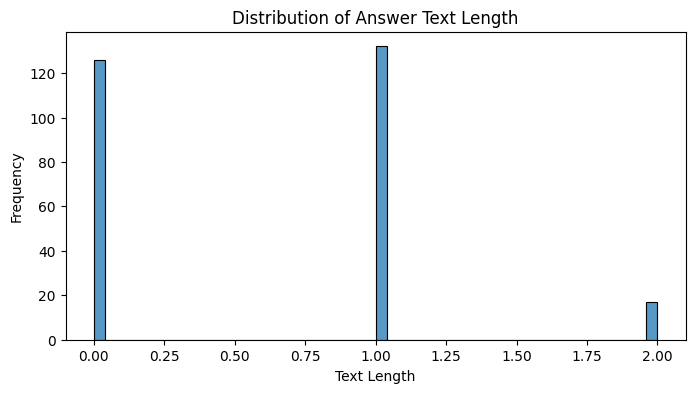

In [11]:
# Visualize the distribution of text length in response to determine if 
# there are extremely long texts and if segmentation is necessary
plt.figure(figsize=(8,4))
sns.histplot(df_qa["answer_len"], bins=50)
plt.title("Distribution of Answer Text Length")
plt.xlabel("Text Length")
plt.ylabel("Frequency")
plt.show()


We analyze the length distribution of analyst questions and executive answers to assess whether the textual data is suitable for downstream NLP tasks.

The results show that analyst questions are relatively long (average length ≈ 650 characters), indicating rich semantic content and sufficient context for sentiment and topic analysis.

However, the extracted answer text has an average length of less than 1 character, with most values concentrated at 0–2 characters. This indicates that the current `answer_text` field does not yet contain the full executive responses.

This finding reveals a data preprocessing issue rather than a property of the original dataset. Specifically, executive responses are stored in the `answers` column as structured objects, and a more robust parsing strategy is required to extract full natural language answers before sentiment modeling.

In [13]:
# The initial assumption was that key=answer_text
# but the inspection revealed the actual situation where key=answer

def extract_answer_text_v2(answer_str):
    """
    Revised answers parsing function
    -Adapt to the 'answer' field used in real data
    -Output a whole natural language text that can be used for NLP
    """
    try:
        answer_list = ast.literal_eval(answer_str)

        # 确保是 list
        if not isinstance(answer_list, list):
            return ""

        texts = []
        for a in answer_list:
            if isinstance(a, dict) and "answer" in a:
                texts.append(a["answer"])

        return " ".join(texts)

    except Exception:
        return ""

In [14]:
df_qa["answer_text"] = df_qa["answers"].apply(extract_answer_text_v2)

In [16]:
df_qa["answer_len"] = df_qa["answer_text"].str.len()
df_qa["answer_len"].describe()

count     275.000000
mean     2463.283636
std      1242.818327
min       286.000000
25%      1575.000000
50%      2318.000000
75%      3263.000000
max      6957.000000
Name: answer_len, dtype: float64

### 3.4 Question–Answer Length Relationship

In earnings calls, more complex or multi-part analyst questions may elicit longer and more detailed responses from company executives.  
In this section, we examine whether there exists a systematic relationship between the length of analyst questions and the corresponding management answers.


In [17]:
# Calculate the length (in characters) of the question/answer
df_qa["question_len"] = df_qa["question_text"].str.len()
df_qa["answer_len"] = df_qa["answer_text"].str.len()

# Check the correlation between the two
# If the correlation is high, it indicates that the 'text length' itself may carry information
df_qa[["question_len", "answer_len"]].corr()

# Based on the output, there is a certain probability that a long question will lead to a longer answer, 
# but it is far from the determining factor

,question_len,answer_len
question_len,1.000000,0.302572
answer_len,0.302572,1.000000


### 3.5 Temporal Distribution of Earnings Calls

Since earnings calls are periodic events, it is important to examine the temporal distribution of the dataset.  
This helps assess whether the sample is evenly distributed over time or concentrated in specific periods.


In [18]:
# Extract year and quarter to determine data uniformity across quarters
df_qa["year"] = df_qa["Quarter"].str[:4]

df_qa["year"].value_counts().sort_index()


year
Q1_2    67
Q2_2    65
Q3_2    75
Q4_2    68
Name: count, dtype: int64

### 3.6 Qualitative Text Inspection

Before proceeding to feature engineering and modeling, we conduct a qualitative inspection of several question–answer pairs.  
This step ensures that the extracted text is coherent, informative, and suitable for downstream NLP analysis such as sentiment modeling.


In [19]:
# Randomly select several QA pairs for manual inspection
df_qa[["question_text", "answer_text"]].sample(3, random_state=42)


,question_text,answer_text
30,"Thanks for taking the questions. One for Mark,...",I can start on the DeepSeek question. I think ...
139,"Great, thank you. One for Mark and one for Dav...",I can talk about the metaverse and Reality Lab...
195,Thanks for taking my questions. I have two. Th...,"Sure. Thanks, Brian. I'll take the first part ..."


Based on the exploratory analysis above, the dataset exhibits sufficient textual richness and structural consistency for downstream NLP-based sentiment modeling.


## 4. Methodology Overview

### 4.1 Analytical Framework

To enhance robustness and interpretability, we adopt a dual-model sentiment modeling framework:

1. A domain-specific pre-trained financial NLP model (FinBERT)
2. A Large Language Model (LLM) API-based sentiment inference module

FinBERT serves as a structured baseline model, producing consistent sentiment labels and probability scores for executive responses.

The LLM module provides contextual interpretation, tone reasoning, and qualitative financial assessment.

This dual-model design allows us to:

- Compare sentiment consistency across models
- Evaluate tone divergence
- Assess financial interpretability
- Construct aggregated sentiment indicators

### 4.2 Sentiment Modeling

This section introduces the sentiment modeling methods used to extract structured sentiment signals from executive responses in earnings calls.

Given that earnings call language is domain-specific and often contains subtle forward-looking tone, a finance-oriented NLP model is used as the baseline approach. In addition, an LLM-based sentiment inference module will later be incorporated to capture contextual nuance and improve interpretability.

The sentiment modeling stage serves two purposes:

1. Convert unstructured management language into structured sentiment indicators
2. Enable comparison between a domain-specific transformer model and an LLM-based approach

### 4.2.1 Baseline Model: FinBERT

As the baseline sentiment model, we use FinBERT, a transformer model pretrained on financial text.

FinBERT is more suitable than general-purpose sentiment tools because earnings call responses contain domain-specific expressions such as guidance, headwinds, capital expenditure, and revenue outlook. These phrases often carry financial tone that generic sentiment models may fail to capture accurately.

For each executive response, FinBERT produces:
- a sentiment label (positive / negative / neutral)
- a confidence score
- class probabilities

These outputs are then used as structured sentiment features for downstream analysis.

In [20]:
# Check if transformers and torch are available
try:
    import transformers
    import torch
    print("transformers and torch are available.")
except Exception as e:
    print("Import failed:", e)

transformers and torch are available.


In [38]:
# Model initialization: cleaning logs+forcing CPU+loading FinBERT


# 1) Turn off tokenizer parallel prompts
os.environ["TOKENIZERS_PARALLELISM"] = "false"

# 2) Try to suppress TensorFlow/CUDA logs as much as possible
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

# 3) Force not to use GPU to avoid CUDA related warnings
os.environ["CUDA_VISIBLE_DEVICES"] = ""


# 4) Close HuggingFace's unnecessary logs
hf_logging.set_verbosity_error()

model_name = "ProsusAI/finbert"

try:
    tokenizer = AutoTokenizer.from_pretrained(
        model_name,
        use_fast=True
    )
    
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name
    )
    
    # Clearly put it on the CPU
    device = torch.device("cpu")
    model.to(device)
    model.eval()
    
    print("FinBERT loaded successfully on CPU.")

except Exception as e:
    print("Failed to load FinBERT:", e)

FinBERT loaded successfully on CPU.


In [40]:
sample_texts = df_qa["answer_text"].dropna().head(5).tolist()

label_map = {
    0: "positive",
    1: "negative",
    2: "neutral"
}

def finbert_predict(text):
    """
   Perform FinBERT emotion classification on a single earnings call answer_text return:
    -Label: emotional label
    -Confidence: the confidence level of the predicted category
    -Probability of each category
    """
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,     # Automatically truncate text when it is too long
        padding=True,
        max_length=512       # Most common length limitation for transformers
    )

    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.nn.functional.softmax(outputs.logits, dim=-1).squeeze().tolist()

    pred_id = int(torch.argmax(outputs.logits, dim=-1).item())
    pred_label = label_map[pred_id]
    confidence = probs[pred_id]

    return {
        "label": pred_label,
        "confidence": confidence,
        "positive_prob": probs[0],
        "negative_prob": probs[1],
        "neutral_prob": probs[2]
    }


In [23]:
# Apply FinBERT to all answer_text applications
finbert_results = df_qa["answer_text"].apply(finbert_predict)

# Expand the model output into structured columns
df_qa["finbert_label"] = finbert_results.apply(lambda x: x["label"])
df_qa["finbert_confidence"] = finbert_results.apply(lambda x: x["confidence"])
df_qa["finbert_positive_prob"] = finbert_results.apply(lambda x: x["positive_prob"])
df_qa["finbert_negative_prob"] = finbert_results.apply(lambda x: x["negative_prob"])
df_qa["finbert_neutral_prob"] = finbert_results.apply(lambda x: x["neutral_prob"])

# View results
df_qa[["answer_text", "finbert_label", "finbert_confidence"]].head()

,answer_text,finbert_label,finbert_confidence
0,Thanks Brian for the question. I think your fi...,neutral,0.676072
1,"Thanks Doug. We're, right now, I would say in ...",neutral,0.703217
2,"Yeah, I mean, a lot of people use Meta Al toda...",neutral,0.795122
3,Thanks Mark. So on the sort of ads improvement...,neutral,0.723287
4,I think it's too early to really understand wh...,neutral,0.885630


In [24]:
# View FinBERT label distribution
df_qa["finbert_label"].value_counts()

finbert_label
neutral     240
positive     27
negative      8
Name: count, dtype: int64

In [25]:
# View confidence distribution
df_qa["finbert_confidence"].describe()

count    275.000000
mean       0.771639
std        0.121819
min        0.425946
25%        0.703174
50%        0.807215
75%        0.873196
max        0.921861
Name: finbert_confidence, dtype: float64

The sentiment classification results show that approximately 87% of the management responses are classified as neutral, while positive and negative tones account for a smaller proportion. This distribution is consistent with the formal and information-driven nature of earnings call communication.

The model exhibits a relatively high confidence level, with an average prediction confidence of 0.77 and a median of 0.81, indicating stable classification performance.

Given the dominance of neutral labels, subsequent analysis will incorporate continuous sentiment scores to capture more subtle tonal variations.

### 4.2.2 Continuous Sentiment Score Construction

While FinBERT provides discrete sentiment labels (positive, neutral, negative), relying solely on categorical outputs may obscure subtle tonal variations in earnings call responses.

To retain sentiment intensity information, we construct a continuous sentiment score based on predicted class probabilities. Specifically, we define the sentiment score as the difference between positive and negative probabilities.

This approach allows us to:

- Capture sentiment direction (optimistic vs. pessimistic)
- Preserve confidence-weighted intensity
- Enable aggregation for time-series financial analysis

Before constructing the score, we first verify whether the probability columns have been preserved from the FinBERT inference step.

In [26]:
# Extract probabilities from the results
df_qa["finbert_positive_prob"] = finbert_results.apply(lambda x: x["positive_prob"])
df_qa["finbert_negative_prob"] = finbert_results.apply(lambda x: x["negative_prob"])
df_qa["finbert_neutral_prob"]  = finbert_results.apply(lambda x: x["neutral_prob"])

# Constructing continuous emotional indicators
df_qa["sentiment_score"] = (
    df_qa["finbert_positive_prob"] - df_qa["finbert_negative_prob"]
)

df_qa["sentiment_score"].describe()

count    275.000000
mean       0.186955
std        0.219935
min       -0.638002
25%        0.073990
50%        0.141175
75%        0.248951
max        0.912859
Name: sentiment_score, dtype: float64

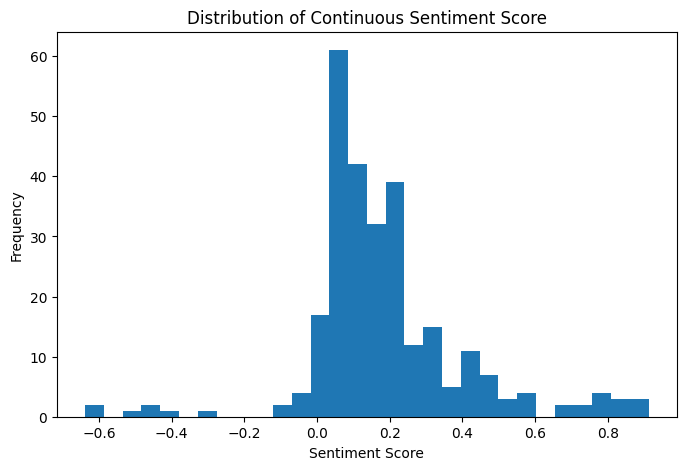

In [27]:
plt.figure(figsize=(8,5))
plt.hist(df_qa["sentiment_score"], bins=30)
plt.title("Distribution of Continuous Sentiment Score")
plt.xlabel("Sentiment Score")
plt.ylabel("Frequency")
plt.show()

The distribution of the continuous sentiment score reveals a moderately positive overall tone in the earnings call responses.

The mean sentiment score is 0.187, while the median is 0.141, indicating that, on average, management responses exhibit a slightly positive sentiment. The interquartile range (0.074 to 0.249) further confirms that the majority of responses cluster within a mildly positive range rather than showing extreme polarity.

Although the minimum score reaches −0.638, negative observations are relatively sparse compared to positive ones, and the maximum score of 0.913 suggests that strongly optimistic responses do occur, but are not dominant.

The histogram demonstrates a right-skewed distribution, with most sentiment scores concentrated between 0 and 0.3. This pattern is consistent with the communicative nature of earnings calls, where management tends to maintain a cautiously optimistic tone while avoiding strongly negative language.

Overall, the continuous sentiment measure provides greater granularity than discrete classification and is suitable for subsequent aggregation and temporal analysis.

### 4.2.3 Consistency Between Discrete and Continuous Sentiment Measures

To evaluate the internal consistency of our sentiment modeling framework, we compare the discrete FinBERT labels with the continuous sentiment score derived from probability-weighted aggregation.

Specifically, we assess:

1. Whether continuous scores align with discrete labels in directional sign

2. Whether neutral classifications conceal mild positive or negative tones

3. The overall correlation between both measures

This comparison helps validate the robustness of our dual-model framework and identify potential systematic bias in discrete classification.

In [28]:
# Discretize continuous scores into three categories for comparison
def continuous_to_label(score):
    if score > 0.05:
        return "positive"
    elif score < -0.05:
        return "negative"
    else:
        return "neutral"

df_qa["continuous_label"] = df_qa["sentiment_score"].apply(continuous_to_label)

# Comparing Discrete FinBERT with Continuous Labels
pd.crosstab(df_qa["finbert_label"], df_qa["continuous_label"])

continuous_label,negative,neutral,positive
finbert_label,,,
negative,8,0,0
neutral,2,38,200
positive,0,0,27


In [29]:
df_qa.groupby("finbert_label")["sentiment_score"].mean()

finbert_label
negative   -0.426308
neutral     0.154215
positive    0.659679
Name: sentiment_score, dtype: float64

In [30]:
# Convert discrete labels to numerical values
label_map = {"negative": -1, "neutral": 0, "positive": 1}
df_qa["finbert_numeric"] = df_qa["finbert_label"].map(label_map)

df_qa[["finbert_numeric", "sentiment_score"]].corr()

,finbert_numeric,sentiment_score
finbert_numeric,1.000000,0.836231
sentiment_score,0.836231,1.000000



The comparison between discrete FinBERT labels and the continuous probability-weighted sentiment score reveals strong directional alignment.

The average continuous sentiment score for each FinBERT category follows a clear monotonic pattern:

- Negative: −0.426

- Neutral: 0.154

- Positive: 0.660

This indicates that the continuous score meaningfully differentiates sentiment intensity across discrete categories. Notably, responses labeled as neutral exhibit a mildly positive average sentiment score, suggesting that FinBERT adopts a conservative threshold when assigning non-neutral classifications.

Furthermore, the correlation between numeric FinBERT labels and the continuous sentiment score is 0.836, demonstrating strong consistency between the two sentiment representations.

Overall, the findings validate the robustness of the dual-model framework. While the discrete classifier captures clear directional sentiment, the continuous score provides additional granularity, allowing for more nuanced aggregation and temporal financial analysis.

### 4.3 Aggregation & Temporal Sentiment Dynamics

While sentence-level sentiment provides micro-level tone signals, financial interpretation requires aggregation across time.  
Therefore, we construct quarterly sentiment indicators to capture macro-level tone dynamics across earnings calls.

This step serves three primary objectives:

1. Transform individual Q&A sentiment into call-level indicators  
2. Examine temporal shifts in corporate tone  
3. Identify potential structural sentiment patterns over time  

We aggregate sentiment using the continuous sentiment score, which preserves intensity information beyond discrete polarity labels.

In [31]:
# Split quarterly information
df_qa["quarter_clean"] = df_qa["Quarter"].str.replace("_", "-")

# Extract year
df_qa["year"] = df_qa["quarter_clean"].str[-4:]

# Extract quarterly number
df_qa["qtr"] = df_qa["quarter_clean"].str[:2]

df_qa[["Quarter", "year", "qtr"]].head()

,Quarter,year,qtr
0,Q3_2025,2025,Q3
1,Q3_2025,2025,Q3
2,Q3_2025,2025,Q3
3,Q3_2025,2025,Q3
4,Q3_2025,2025,Q3


In [32]:
# Calculate quarterly average sentiment
quarter_sentiment = (
    df_qa
    .groupby("Quarter")["sentiment_score"]
    .mean()
    .reset_index()
)

quarter_sentiment

,Quarter,sentiment_score
0,Q1_2019,0.127333
1,Q1_2020,0.117661
2,Q1_2021,0.160554
3,Q1_2022,0.035274
4,Q1_2023,0.274195
5,Q1_2024,0.336459
6,Q1_2025,0.249706
7,Q2_2019,0.195977
8,Q2_2020,0.103106
9,Q2_2021,0.174434


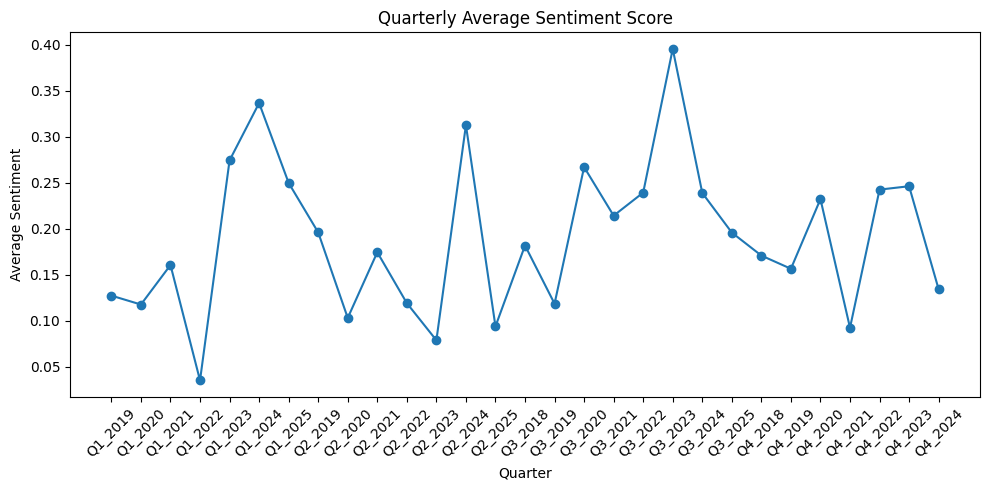

In [33]:
plt.figure(figsize=(10,5))
plt.plot(quarter_sentiment["Quarter"], quarter_sentiment["sentiment_score"], marker="o")
plt.xticks(rotation=45)
plt.title("Quarterly Average Sentiment Score")
plt.xlabel("Quarter")
plt.ylabel("Average Sentiment")
plt.tight_layout()
plt.show()

In [34]:
# Quarterly positive ratio
quarter_total = df_qa.groupby("Quarter").size()
quarter_positive = df_qa[df_qa["finbert_label"] == "positive"].groupby("Quarter").size()

quarter_positive_ratio = (quarter_positive / quarter_total).fillna(0)

quarter_positive_ratio

Quarter
Q1_2019    0.000000
Q1_2020    0.125000
Q1_2021    0.000000
Q1_2022    0.100000
Q1_2023    0.111111
Q1_2024    0.333333
Q1_2025    0.222222
Q2_2019    0.153846
Q2_2020    0.000000
Q2_2021    0.000000
Q2_2022    0.111111
Q2_2023    0.000000
Q2_2024    0.333333
Q2_2025    0.000000
Q3_2018    0.090909
Q3_2019    0.000000
Q3_2020    0.222222
Q3_2021    0.100000
Q3_2022    0.125000
Q3_2023    0.428571
Q3_2024    0.111111
Q3_2025    0.000000
Q4_2018    0.000000
Q4_2019    0.071429
Q4_2020    0.125000
Q4_2021    0.000000
Q4_2022    0.200000
Q4_2023    0.000000
Q4_2024    0.000000
dtype: float64

The quarterly sentiment dynamics exhibit moderate fluctuations without a clear long-term upward or downward trend.  
While the overall tone remains slightly positive on average, certain quarters demonstrate pronounced sentiment spikes.

These fluctuations likely reflect event-driven communication patterns, such as earnings surprises, strategic announcements, or macroeconomic conditions, rather than structural shifts in managerial tone.

This suggests that earnings call sentiment may function as a short-term informational signal rather than a persistent behavioral bias.

### 4.4 Financial Interpretation & Research Implications


#### 4.4.1 Managerial Tone as an Informational Signal

The earnings call sentiment analysis reveals that managerial responses are predominantly neutral, with a moderate positive skew. 

The continuous sentiment score further confirms that while extreme negative tones are rare, positive spikes are episodically observed.

This pattern suggests that managerial tone is generally controlled and strategically moderated, but exhibits variability in response to firm-specific developments.

Such variability may contain incremental information beyond numerical financial disclosures.


#### 4.4.2 Event-Driven Sentiment Fluctuations

The temporal aggregation results indicate that sentiment fluctuates across quarters without a persistent upward or downward trend.

Certain quarters display noticeable sentiment spikes or drops, implying that tone may respond to:

- Earnings surprises
- Product launches
- Regulatory events
- Macro-financial conditions

This supports the hypothesis that sentiment behaves as a short-term event-driven communication signal.


#### 4.4.3 Potential Asset Pricing Implications

From a financial perspective, managerial tone in earnings calls may influence:

- Investor expectations
- Analyst revisions
- Post-earnings announcement drift (PEAD)
- Short-term return volatility

Aggregated sentiment indicators may serve as:

- A cross-sectional explanatory variable
- A risk sentiment proxy
- A behavioral finance factor


#### 4.4.4 Research Extensions

Future extensions may include:

1. Linking sentiment to abnormal returns
2. Testing predictive power on next-quarter earnings growth
3. Comparing Q&A tone vs prepared remarks tone
4. Constructing sentiment-based trading strategies

The present analysis establishes a robust sentiment measurement pipeline, enabling further financial modeling applications.

## 5. Text-Based Risk Factor Construction

To translate qualitative earnings call tone into quantitative risk indicators, we construct text-based risk factors at the quarterly level.

The first factor is the **Average Sentiment Factor**, defined as the mean continuous sentiment score across all executive responses within each quarter.

This factor captures the overall directional tone of management communication and serves as a high-level qualitative risk signal.

### 5.1 Average Sentiment Factor

In [35]:
# Ensure Quarter is string
df_qa["Quarter"] = df_qa["Quarter"].astype(str)

# Quarterly average sentiment
avg_sentiment = (
    df_qa.groupby("Quarter")["sentiment_score"]
    .mean()
    .reset_index()
    .rename(columns={"sentiment_score": "avg_sentiment"})
)

avg_sentiment.head()

,Quarter,avg_sentiment
0,Q1_2019,0.127333
1,Q1_2020,0.117661
2,Q1_2021,0.160554
3,Q1_2022,0.035274
4,Q1_2023,0.274195


### 5.2 Downside Sentiment Ratio

The second factor measures the proportion of responses classified as negative within each quarter.

This indicator captures explicit downside communication and may reflect risk disclosure intensity or cautious managerial tone.

In [36]:
downside_ratio = (
    df_qa.assign(is_negative=(df_qa["finbert_label"] == "negative").astype(int))
    .groupby("Quarter")["is_negative"]
    .mean()
    .reset_index()
    .rename(columns={"is_negative": "downside_ratio"})
)

downside_ratio.head()

,Quarter,downside_ratio
0,Q1_2019,0.000
1,Q1_2020,0.125
2,Q1_2021,0.000
3,Q1_2022,0.200
4,Q1_2023,0.000


### 5.3 Sentiment Dispersion and Sentiment Shock

Beyond directional tone, we also measure uncertainty and abrupt communication changes.

- **Sentiment Dispersion** is defined as the cross-sectional standard deviation of sentiment scores within a quarter. Higher dispersion may indicate inconsistent messaging or elevated uncertainty.

- **Sentiment Shock** is defined as the quarter-over-quarter change in the average sentiment factor. Large shifts may signal structural changes in managerial outlook.

In [37]:
# Sentiment dispersion
dispersion = (
    df_qa.groupby("Quarter")["sentiment_score"]
    .std()
    .reset_index()
    .rename(columns={"sentiment_score": "sentiment_dispersion"})
)

# Merge factors
risk_factor_df = avg_sentiment.merge(downside_ratio, on="Quarter")
risk_factor_df = risk_factor_df.merge(dispersion, on="Quarter")

# Sort quarters correctly
def quarter_sort_key(q):
    qtr, year = q.split("_")
    return int(year), int(qtr[1])

risk_factor_df = risk_factor_df.sort_values(
    by="Quarter",
    key=lambda col: col.map(quarter_sort_key)
).reset_index(drop=True)

# Sentiment shock
risk_factor_df["sentiment_shock"] = risk_factor_df["avg_sentiment"].diff()

risk_factor_df.head()

,Quarter,avg_sentiment,downside_ratio,sentiment_dispersion,sentiment_shock
0,Q3_2018,0.181761,0.0,0.211466,NaN
1,Q4_2018,0.170819,0.0,0.118060,-0.010941
2,Q1_2019,0.127333,0.0,0.099001,-0.043486
3,Q2_2019,0.195977,0.0,0.189373,0.068644
4,Q3_2019,0.118576,0.0,0.082820,-0.077401


### 5.4 Interpretation of Text-Based Risk Factors

The constructed text-based risk factors reveal several meaningful patterns in managerial communication.

First, the **average sentiment factor** remains positive in most quarters, suggesting that management tone is generally optimistic or at least non-negative. However, its variation across quarters indicates that communication tone is not constant and may reflect changing business conditions.

Second, the **downside sentiment ratio** is zero in many quarters and only rises in selected periods. This suggests that explicitly negative language is relatively rare in earnings call responses. As a result, downside sentiment appears to function more as a low-frequency tail-risk signal than as a regular communication feature.

Third, the **sentiment dispersion** factor varies across quarters, indicating that management responses are sometimes internally consistent and sometimes more heterogeneous in tone. This measure may therefore serve as a qualitative proxy for communication uncertainty or inconsistency.

Finally, the **sentiment shock** measure captures abrupt quarter-over-quarter changes in tone. Large positive or negative changes may indicate shifts in managerial outlook and can be interpreted as potential early warning signals in a qualitative risk monitoring framework.

Overall, these results suggest that earnings call language can be summarized into compact text-based risk factors that capture tone level, downside communication, internal uncertainty, and communication regime shifts.

## 6. Conclusion and Limitations

### 6.1 Conclusion

This project develops a structured AI-driven framework to extract and analyze sentiment signals from earnings call transcripts.

By combining a domain-specific financial NLP model (FinBERT) with continuous probability-weighted sentiment scores, we construct interpretable sentiment measures at the response level and aggregate them into quarterly text-based risk factors.

The empirical analysis shows that managerial tone is generally positive but exhibits meaningful time variation, occasional downside spikes, dispersion across responses, and abrupt sentiment shifts. These dynamics suggest that earnings call language contains structured qualitative information that may complement traditional numerical financial indicators.

The constructed sentiment factors — including average tone, downside ratio, dispersion, and sentiment shock — provide a compact representation of managerial communication risk and may serve as potential inputs for future financial modeling, risk monitoring, or asset pricing research.

---

### 6.2 Limitations

Several limitations should be acknowledged.

First, the analysis focuses on a single company (META), which limits cross-sectional generalizability.  
Second, the study does not formally test predictive relationships between sentiment factors and financial outcomes such as returns or volatility.  
Third, earnings call transcripts may reflect strategic communication rather than purely informational content, potentially introducing tone management bias.  
Finally, while FinBERT captures financial domain language effectively, more advanced LLM-based contextual modeling could further enhance interpretability.

Future work may extend this framework to multi-firm datasets, incorporate event studies, and evaluate the predictive power of text-derived risk factors in a formal econometric setting.